# 제출파일 1. 서울 아파트 상승률 예측: EDA, 전처리, ver16 평가 재현

이 노트북은 최종 서비스 후보인 `ver16_hierarchical_apt_size_residual`의 데이터와 평가 절차를 검증한다. 단순히 저장된 성능 JSON을 출력하지 않고 다음을 직접 수행한다.

1. 학습 feature store의 스키마와 데이터 범위를 확인한다.
2. horizon별 시간 순서 분할을 재현하고 시간 누수가 없는지 검사한다.
3. ver9b base 예측과 최근 validation 3개월 잔차로 ver16 계층형 보정값을 다시 계산한다.
4. 265,404개 test 표본에서 MAE, RMSE, R², Spearman, P80/P90을 직접 계산한다.

> 기본 실행은 약 1.1GB feature store를 필요한 열만 읽어 메모리 사용을 줄인다. 전체 LightGBM 재학습은 마지막 선택 셀에서 별도로 실행할 수 있다.


In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

def find_ml_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd / 'ml_model', cwd.parent / 'ml_model', cwd.parent.parent / 'ml_model']
    for candidate in candidates:
        if (candidate / 'config' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('ml_model/config/config.yaml을 찾을 수 없습니다.')

ML_DIR = find_ml_dir()
APP_DIR = ML_DIR.parent
SRC_DIR = ML_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

PIPELINE_CONFIG_PATH = ML_DIR / 'config' / 'config.yaml'
BASE_CONFIG_PATH = ML_DIR / 'config' / 'config_ver9b_multihorizon_calibrated.yaml'
DATA_PATH = APP_DIR / 'data' / 'integration' / 'apartment_multihorizon_ver9_stability_features.csv'

with PIPELINE_CONFIG_PATH.open(encoding='utf-8') as f:
    pipeline_config = yaml.safe_load(f)
with BASE_CONFIG_PATH.open(encoding='utf-8') as f:
    base_config = yaml.safe_load(f)

pipeline_files = sorted((ML_DIR / 'outputs').glob('pipeline_ver16_hierarchical_apt_size_residual_*.json'))
assert pipeline_files, 'ver16 pipeline 실행 결과 JSON이 필요합니다.'
PIPELINE_RESULT_PATH = pipeline_files[-1]
pipeline_result = json.loads(PIPELINE_RESULT_PATH.read_text(encoding='utf-8'))

def local_artifact(path_text: str, folder: str) -> Path:
    return ML_DIR / 'outputs' / folder / Path(path_text).name

prediction_paths = pipeline_result['train_result']['prediction_paths']
VALID_PRED_PATH = local_artifact(prediction_paths['valid'], 'predictions')
TEST_PRED_PATH = local_artifact(prediction_paths['test'], 'predictions')
COMPLEX_OFFSET_PATH = ML_DIR / 'outputs' / 'calibration' / 'ver12c_recent3_horizon_complex_residual_offsets.csv'
GROUP_OFFSET_PATH = ML_DIR / 'outputs' / 'calibration' / 'ver12d_group_residual_fallback_offsets.csv'
VER16_OFFSET_PATH = ML_DIR / 'outputs' / 'calibration' / 'ver16_hierarchical_apt_size_offsets.csv'

required_paths = [DATA_PATH, VALID_PRED_PATH, TEST_PRED_PATH, COMPLEX_OFFSET_PATH, GROUP_OFFSET_PATH, VER16_OFFSET_PATH]
missing_paths = [str(path) for path in required_paths if not path.exists()]
assert not missing_paths, f'필수 파일이 없습니다: {missing_paths}'

display(pd.DataFrame({'artifact': [p.name for p in required_paths], 'size_mb': [round(p.stat().st_size / 1024**2, 2) for p in required_paths]}))


,artifact,size_mb
0,apartment_multihorizon_ver9_stability_features...,1053.76
1,predictions_valid_target_return_pct_20260622_2...,27.69
2,predictions_test_target_return_pct_20260622_23...,28.00
3,ver12c_recent3_horizon_complex_residual_offset...,1.35
4,ver12d_group_residual_fallback_offsets.csv,0.02
5,ver16_hierarchical_apt_size_offsets.csv,6.33


## 1. 분석 단위와 특징 설계

한 행은 특정 `단지-평형(apt_size_id)`의 기준월과 예측기간(`horizon_months`) 조합이다. 라벨은 기준월 KB 매매시세 대비 horizon 이후 KB 매매시세의 상승률(%p)이다. 실거래 평균·거래량은 서비스 시점에 안정적으로 확보하기 어렵다고 판단해 최종 특징에서 제외했다.


In [2]:
from ml_project.preprocessing import resolve_feature_columns

feature_columns = resolve_feature_columns(base_config)
header_columns = pd.read_csv(DATA_PATH, nrows=0, encoding='utf-8-sig').columns.tolist()
missing_features = sorted(set(feature_columns) - set(header_columns))
assert not missing_features, f'feature store에 없는 학습 열: {missing_features}'

feature_set_rows = []
for set_name in base_config['data']['active_feature_sets']:
    columns = base_config['data']['feature_sets'][set_name]
    feature_set_rows.append({'feature_set': set_name, 'count': len(columns), 'columns': ', '.join(columns)})
display(pd.DataFrame(feature_set_rows))
print(f'최종 입력 특징 수: {len(feature_columns)}개')
print(f"범주형 특징: {base_config['data']['categorical_columns']}")


,feature_set,count,columns
0,horizon,1,horizon_months
1,kb_market,4,"kb_sale_price_manwon, kb_jeonse_price_manwon, ..."
2,apartment_meta,15,"gu, lat, lon, households_total, built_yyyymm, ..."
3,poi_accessibility,18,"nearest_station_m, station_count_500m, station..."
4,individual_stability_without_actual_tx,17,"built_year, built_month, building_age_years, s..."


최종 입력 특징 수: 55개
범주형 특징: ['gu', 'property_type', 'housing_type']


## 2. EDA: 범위, 개체 수, 라벨 분포

EDA에는 분석 단위·분할·대표 특징을 설명하는 열만 읽는다. 학습 스키마 전체는 위에서 별도로 검증했으며, 결측률은 아래에서 20만 행 표본으로 확인한다. 이는 1.1GB 파일을 노트북에서 중복 적재하지 않기 위한 의도적인 메모리 통제다.


In [3]:
eda_columns = [
    'apt_size_id', 'complex_id', 'date', 'future_date', 'horizon_months',
    'gu', 'exclusive_area_pyeong', 'target_return_pct', 'kb_sale_price_manwon'
]
eda = pd.read_csv(
    DATA_PATH, usecols=eda_columns, encoding='utf-8-sig',
    parse_dates=['date', 'future_date'], low_memory=False
)

overview = pd.Series({
    'rows': len(eda),
    'date_min': eda['date'].min().date(),
    'date_max': eda['date'].max().date(),
    'complexes': eda['complex_id'].nunique(),
    'apartment_size_units': eda['apt_size_id'].nunique(),
    'districts': eda['gu'].nunique(),
})
display(overview.to_frame('value'))
display(eda['target_return_pct'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame())
display(eda.groupby('horizon_months', observed=True).agg(rows=('apt_size_id', 'size'), dates=('date', 'nunique'), target_mean=('target_return_pct', 'mean'), target_std=('target_return_pct', 'std')))


,value
rows,1569946
date_min,2021-06-01
date_max,2025-06-01
complexes,4527
apartment_size_units,18894
districts,21


,target_return_pct
count,1.569946e+06
mean,1.859277e+00
std,1.204640e+01
min,-4.038462e+01
10%,-1.076923e+01
25%,-4.285714e+00
50%,0.000000e+00
75%,5.607477e+00
90%,1.673004e+01
max,1.583333e+02


,rows,dates,target_mean,target_std
horizon_months,,,,
12,641150,49,1.708529,8.823456
24,452865,37,1.038990,12.462384
36,305314,25,1.345090,14.163183
48,158451,13,4.661392,15.479328
60,12166,1,16.746800,18.183589


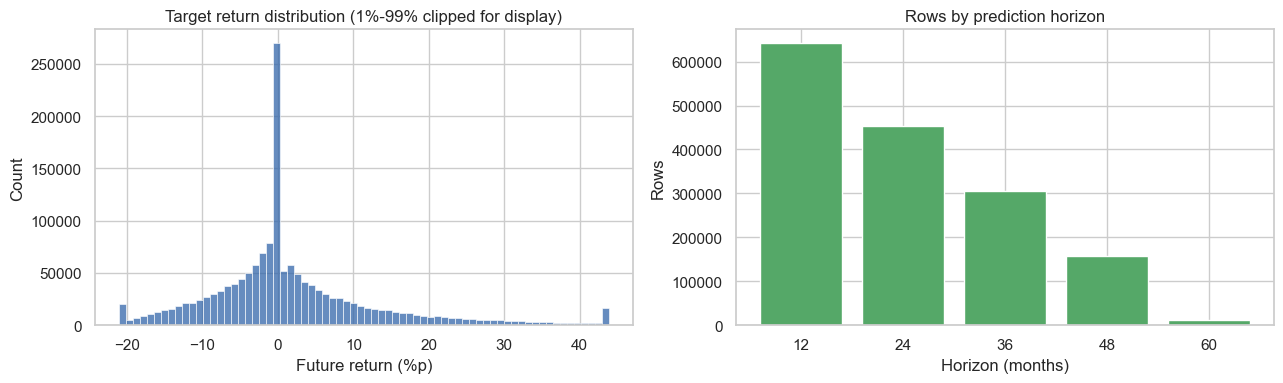

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_target = eda['target_return_pct'].clip(eda['target_return_pct'].quantile(0.01), eda['target_return_pct'].quantile(0.99))
sns.histplot(plot_target, bins=70, ax=axes[0], color='#3366aa')
axes[0].set_title('Target return distribution (1%-99% clipped for display)')
axes[0].set_xlabel('Future return (%p)')
horizon_counts = eda['horizon_months'].value_counts().sort_index()
axes[1].bar(horizon_counts.index.astype(str), horizon_counts.values, color='#55a868')
axes[1].set_title('Rows by prediction horizon')
axes[1].set_xlabel('Horizon (months)')
axes[1].set_ylabel('Rows')
plt.tight_layout()
plt.show()


In [5]:
feature_sample = pd.read_csv(DATA_PATH, usecols=feature_columns, nrows=200_000, encoding='utf-8-sig', low_memory=False)
missing_rate = feature_sample.isna().mean().mul(100).sort_values(ascending=False)
display(missing_rate.head(15).rename('missing_pct').to_frame())
assert np.isfinite(pd.to_numeric(eda['target_return_pct'], errors='coerce')).all(), '라벨에 비수치 값이 있습니다.'
month_delta = (eda['future_date'].dt.year - eda['date'].dt.year) * 12 + (eda['future_date'].dt.month - eda['date'].dt.month)
assert month_delta.eq(eda['horizon_months']).all(), '기준월과 미래월 간격이 horizon과 일치하지 않습니다.'
print('라벨 유한값 및 date + horizon = future_date 검증 통과')


,missing_pct
housing_type,61.7695
kb_jeonse_ratio_pct,1.6845
kb_price_gap_manwon,1.6845
kb_sale_price_manwon,0.0000
log_households_total,0.0000
nearest_hospital_m,0.0000
hospital_count_3000m,0.0000
hospital_count_5000m,0.0000
hospital_doctor_sum_3000m,0.0000
hospital_doctor_sum_5000m,0.0000


라벨 유한값 및 date + horizon = future_date 검증 통과


### 결측치 처리 결정

20만 행 점검에서 `housing_type` 결측률이 약 61.8%로 가장 높고, 전세가율·시세갭은 약 1.7%가 비어 있다. `housing_type`을 최빈값으로 채우면 실제로 알 수 없는 유형을 특정 유형으로 왜곡하므로 결측 상태를 유지했다. LightGBM은 결측 분기를 학습할 수 있지만, 높은 결측률은 해당 특징의 해석과 일반화에 주의해야 할 한계다.


## 3. 전처리와 시간 분할

무작위 분할은 미래 시장 국면이 과거 학습 행에 섞이는 시간 누수를 만들 수 있다. 따라서 각 horizon에서 마지막 5개 기준월을 test, 그 직전 5개 기준월을 validation으로 두고 나머지를 train으로 사용한다. 60개월은 완성된 라벨 기준월이 1개뿐이므로 학습에는 포함하지만 평가하지 않는다.


In [6]:
def assign_time_split(frame: pd.DataFrame, valid_tail=5, test_tail=5) -> pd.Series:
    labels = pd.Series('train', index=frame.index, dtype='string')
    for horizon, group in frame.groupby('horizon_months', observed=True):
        dates = sorted(group['date'].dropna().unique())
        if len(dates) < 1 + valid_tail + test_tail:
            continue
        valid_dates = set(dates[-(valid_tail + test_tail):-test_tail])
        test_dates = set(dates[-test_tail:])
        labels.loc[group.index[group['date'].isin(valid_dates)]] = 'valid'
        labels.loc[group.index[group['date'].isin(test_dates)]] = 'test'
    return labels.astype('category')

eda['split'] = assign_time_split(eda)
split_summary = eda.groupby(['horizon_months', 'split'], observed=True).agg(rows=('apt_size_id', 'size'), min_date=('date', 'min'), max_date=('date', 'max')).reset_index()
display(split_summary)
display(eda['split'].value_counts().reindex(['train', 'valid', 'test']).rename('rows').to_frame())

for horizon, group in eda.groupby('horizon_months', observed=True):
    valid = group[group['split'].eq('valid')]
    test = group[group['split'].eq('test')]
    if valid.empty or test.empty:
        continue
    train = group[group['split'].eq('train')]
    assert train['date'].max() < valid['date'].min() < test['date'].min()

assert eda['split'].value_counts()['test'] == 265_404
print('horizon별 시간 순서와 test 265,404행 검증 통과')


,horizon_months,split,rows,min_date,max_date
0,12,test,82571,2025-02-01,2025-06-01
1,12,train,478632,2021-06-01,2024-08-01
2,12,valid,79947,2024-09-01,2025-01-01
3,24,test,60953,2024-02-01,2024-06-01
4,24,train,330908,2021-06-01,2023-08-01
5,24,valid,61004,2023-09-01,2024-01-01
6,36,test,60952,2023-02-01,2023-06-01
7,36,train,183359,2021-06-01,2022-08-01
8,36,valid,61003,2022-09-01,2023-01-01
9,48,test,60928,2022-02-01,2022-06-01


,rows
split,
train,1041652
valid,262890
test,265404


horizon별 시간 순서와 test 265,404행 검증 통과


## 4. 저장된 base 예측과 평가 데이터 결합

ver9b는 하나의 LightGBM에 `horizon_months`를 입력하는 multi-horizon 회귀 모델이다. 아래에서는 최신 재현 실행이 저장한 validation/test 예측을 읽고, feature store에서 보정 계층에 필요한 구·전용평형 정보만 결합한다.


In [7]:
join_keys = ['apt_size_id', 'complex_id', 'date', 'horizon_months']
feature_lookup = eda[join_keys + ['gu', 'exclusive_area_pyeong']].drop_duplicates(join_keys)

def load_predictions(path: Path) -> pd.DataFrame:
    pred = pd.read_csv(path, encoding='utf-8-sig', parse_dates=['date'])
    pred = pred.merge(feature_lookup, on=join_keys, how='left', validate='many_to_one')
    pred['area_bin'] = pd.cut(
        pd.to_numeric(pred['exclusive_area_pyeong'], errors='coerce'),
        bins=[-1, 18, 25, 34, 45, 1000], labels=['a18', 'a25', 'a34', 'a45', 'a45p']
    ).astype(str)
    assert pred[['gu', 'exclusive_area_pyeong']].notna().all().all()
    return pred

valid_pred = load_predictions(VALID_PRED_PATH)
test_pred = load_predictions(TEST_PRED_PATH)
assert len(valid_pred) == 262_890 and len(test_pred) == 265_404
print({'valid_rows': len(valid_pred), 'test_rows': len(test_pred), 'prediction_column': 'prediction_calibrated'})


{'valid_rows': 262890, 'test_rows': 265404, 'prediction_column': 'prediction_calibrated'}


In [8]:
def metric_dict(y_true, y_pred) -> dict:
    y_true = pd.Series(y_true, dtype=float).reset_index(drop=True)
    y_pred = pd.Series(y_pred, dtype=float).reset_index(drop=True)
    error = y_pred - y_true
    abs_error = error.abs()
    ss_res = float(np.sum(error.to_numpy() ** 2))
    ss_tot = float(np.sum((y_true.to_numpy() - y_true.mean()) ** 2))
    return {
        'rows': len(y_true),
        'mae': float(abs_error.mean()),
        'rmse': float(np.sqrt(np.mean(error.to_numpy() ** 2))),
        'r2': float(1 - ss_res / ss_tot),
        'spearman': float(y_true.rank().corr(y_pred.rank())),
        'bias': float(error.mean()),
        'p80_abs_error': float(abs_error.quantile(0.8)),
        'p90_abs_error': float(abs_error.quantile(0.9)),
    }

ver9b_metrics = metric_dict(test_pred['target_return_pct'], test_pred['prediction_calibrated'])
display(pd.Series(ver9b_metrics, name='ver9b_base').to_frame())


,ver9b_base
rows,265404.000000
mae,8.228504
rmse,12.185187
r2,0.366226
spearman,0.669507
bias,-4.357390
p80_abs_error,13.119633
p90_abs_error,20.366731


## 5. ver16 계층형 residual 보정 재생성

base 오차의 반복 패턴을 단지·평형별로 보정한다. 최근 validation 3개월에서 `실제 상승률 - base 예측`을 계산하고, 표본이 적을수록 단지·horizon → 구·면적 그룹 → horizon 전체 → 전체 평균 prior 쪽으로 축소한다. test 라벨은 보정값 생성에 사용하지 않는다.

`offset = prior + n / (n + 0.5) × (raw_mean - prior)`


In [9]:
complex_offsets = pd.read_csv(COMPLEX_OFFSET_PATH, encoding='utf-8-sig')
group_offsets = pd.read_csv(GROUP_OFFSET_PATH, encoding='utf-8-sig')

def map_prior_offsets(target: pd.DataFrame) -> pd.Series:
    exact = complex_offsets[complex_offsets['complex_id'].ne(-1)].set_index(['complex_id', 'horizon_months'])['residual_offset']
    horizon = complex_offsets[complex_offsets['complex_id'].eq(-1)].set_index('horizon_months')['residual_offset']
    global_offset = float(complex_offsets['global_offset'].iloc[0])
    group = group_offsets.set_index(['horizon_months', 'gu', 'area_bin'])['residual_offset']
    exact_idx = pd.MultiIndex.from_frame(target[['complex_id', 'horizon_months']])
    group_idx = pd.MultiIndex.from_frame(target[['horizon_months', 'gu', 'area_bin']])
    exact_map = pd.Series(exact_idx.map(exact), index=target.index, dtype=float)
    group_map = pd.Series(group_idx.map(group), index=target.index, dtype=float)
    horizon_map = target['horizon_months'].map(horizon).astype(float)
    return exact_map.fillna(group_map).fillna(horizon_map).fillna(global_offset)

def latest_validation_months(frame: pd.DataFrame, months=3) -> pd.DataFrame:
    parts = []
    for _, group in frame.groupby('horizon_months', observed=True):
        dates = sorted(group['date'].unique())[-months:]
        parts.append(group[group['date'].isin(dates)])
    return pd.concat(parts, ignore_index=True)

source = latest_validation_months(valid_pred, months=3)
source['raw_residual'] = source['target_return_pct'] - source['prediction_calibrated']
source['prior_offset'] = map_prior_offsets(source).to_numpy()

ver16_offsets = source.groupby(['apt_size_id', 'horizon_months'], observed=True).agg(
    raw_mean=('raw_residual', 'mean'), prior_mean=('prior_offset', 'mean'), valid_rows=('raw_residual', 'size')
).reset_index()
ver16_offsets['shrink_weight'] = ver16_offsets['valid_rows'] / (ver16_offsets['valid_rows'] + 0.5)
ver16_offsets['residual_offset'] = ver16_offsets['prior_mean'] + ver16_offsets['shrink_weight'] * (ver16_offsets['raw_mean'] - ver16_offsets['prior_mean'])

stored_offsets = pd.read_csv(VER16_OFFSET_PATH, encoding='utf-8-sig')
offset_check = ver16_offsets.merge(stored_offsets[['apt_size_id', 'horizon_months', 'residual_offset']], on=['apt_size_id', 'horizon_months'], suffixes=('_rebuilt', '_stored'), validate='one_to_one')
max_offset_diff = (offset_check['residual_offset_rebuilt'] - offset_check['residual_offset_stored']).abs().max()
assert len(offset_check) == len(stored_offsets) == len(ver16_offsets)
assert max_offset_diff < 1e-10
print({'source_rows': len(source), 'offset_rows': len(ver16_offsets), 'max_rebuild_diff': max_offset_diff})


{'source_rows': 158659, 'offset_rows': 53769, 'max_rebuild_diff': 7.105427357601002e-15}


In [10]:
test_prior = map_prior_offsets(test_pred)
offset_lookup = ver16_offsets.set_index(['apt_size_id', 'horizon_months'])['residual_offset']
test_idx = pd.MultiIndex.from_frame(test_pred[['apt_size_id', 'horizon_months']])
apt_offset = pd.Series(test_idx.map(offset_lookup), index=test_pred.index, dtype=float)
fallback = pd.Series(np.where(apt_offset.notna(), 'hier_apt_size_id+horizon', 'ver12d_base'), index=test_pred.index)
final_prediction = test_pred['prediction_calibrated'] + apt_offset.fillna(test_prior)

final_metrics = metric_dict(test_pred['target_return_pct'], final_prediction)
display(pd.DataFrame({'ver9b': ver9b_metrics, 'ver16': final_metrics}))

by_horizon = []
for horizon, group in test_pred.groupby('horizon_months', observed=True):
    metrics = metric_dict(group['target_return_pct'], final_prediction.loc[group.index])
    by_horizon.append({'horizon_months': int(horizon), **metrics})
display(pd.DataFrame(by_horizon).set_index('horizon_months'))
display(fallback.value_counts().rename('rows').to_frame())


,ver9b,ver16
rows,265404.000000,265404.000000
mae,8.228504,5.037594
rmse,12.185187,8.171132
r2,0.366226,0.715007
spearman,0.669507,0.871469
bias,-4.357390,-3.624062
p80_abs_error,13.119633,8.633642
p90_abs_error,20.366731,13.691083


,rows,mae,rmse,r2,spearman,bias,p80_abs_error,p90_abs_error
horizon_months,,,,,,,,
12,82571,4.895541,7.789203,0.513251,0.770256,-2.133008,8.267440,12.844732
24,60953,4.919416,8.101598,0.741470,0.912411,-4.286776,8.597144,13.857206
36,60952,6.068367,9.712255,0.701044,0.893529,-5.552446,10.455634,16.806002
48,60928,4.317154,6.970585,0.811659,0.913526,-3.052642,7.570073,11.804498


,rows
hier_apt_size_id+horizon,262251
ver12d_base,3153


## 6. 최종 성능 검증

아래 assertion은 발표·문서에 사용한 수치가 현재 데이터와 산출물에서 동일하게 재현되는지 확인한다. MAE와 RMSE의 단위는 상승률의 percentage point(%p)다.


In [11]:
expected = pipeline_config['performance']
checks = {
    'test_mae': final_metrics['mae'],
    'test_rmse': final_metrics['rmse'],
    'test_r2': final_metrics['r2'],
    'test_spearman': final_metrics['spearman'],
    'test_p80': final_metrics['p80_abs_error'],
    'test_p90': final_metrics['p90_abs_error'],
}
for key, actual in checks.items():
    assert np.isclose(actual, float(expected[key]), atol=5e-5), (key, actual, expected[key])

improvement_pct = (ver9b_metrics['mae'] - final_metrics['mae']) / ver9b_metrics['mae'] * 100
summary = pd.Series({
    'ver9b_test_mae': ver9b_metrics['mae'],
    'ver16_test_mae': final_metrics['mae'],
    'mae_improvement_pct': improvement_pct,
    'ver16_test_rmse': final_metrics['rmse'],
    'ver16_test_r2': final_metrics['r2'],
    'ver16_test_spearman': final_metrics['spearman'],
    'ver16_p80_abs_error': final_metrics['p80_abs_error'],
    'ver16_p90_abs_error': final_metrics['p90_abs_error'],
})
display(summary.to_frame('value'))
print('문서 기재 성능과 재계산 결과 일치: PASS')


,value
ver9b_test_mae,8.228504
ver16_test_mae,5.037594
mae_improvement_pct,38.778740
ver16_test_rmse,8.171132
ver16_test_r2,0.715007
ver16_test_spearman,0.871469
ver16_p80_abs_error,8.633642
ver16_p90_abs_error,13.691083


문서 기재 성능과 재계산 결과 일치: PASS


## 7. 선택 실행: base 모델부터 전체 재학습

기본 실행은 제출 검증 시간을 줄이기 위해 기존 재현 실행의 base 예측을 사용했다. 아래 셀은 `RUN_VER16_FULL_TRAIN=1` 환경변수를 설정했을 때 `config/config.yaml`로 base LightGBM 학습과 ver16 후처리를 다시 실행한다. 전체 feature store를 읽으므로 충분한 메모리와 시간이 필요하며 기존 산출물 폴더에 새 timestamp 결과를 추가한다.


In [12]:
RUN_FULL_TRAIN = os.getenv('RUN_VER16_FULL_TRAIN', '0') == '1'
if RUN_FULL_TRAIN:
    from ml_project.train import run_pipeline
    full_train_result = run_pipeline(PIPELINE_CONFIG_PATH)
    display(full_train_result)
else:
    print('전체 재학습 생략. 실행하려면 PowerShell에서 $env:RUN_VER16_FULL_TRAIN="1" 설정 후 노트북을 실행하세요.')


전체 재학습 생략. 실행하려면 PowerShell에서 $env:RUN_VER16_FULL_TRAIN="1" 설정 후 노트북을 실행하세요.


## 결론과 해석 범위

- ver16은 ver9b base의 test MAE 8.2285%p를 5.0376%p로 38.8% 개선했다.
- 이 값은 개별 단지·평형의 상승률 오차이며, 투자수익 보장이나 인과효과를 의미하지 않는다.
- 12/24/36/48개월은 test로 평가했지만, 60개월은 완성 라벨 기간이 부족해 정식 test 성능을 주장하지 않는다. 서비스에서는 60개월을 low confidence로 표시해야 한다.
- P80/P90은 통계적 신뢰구간이 아니라 test 절대오차의 경험적 분위수다.
